# Spectral fitting example (AGN)


This notebook fits the spectrum of a simulated AGN observation with COSI using the same 3ML workflow as the Crab spectral fitting tutorial.

The binned mock data already include background. The fit uses a separate total-background template with a free normalization, and models the selected AGN source or sources as cutoff-power-law thermal components with optional simple-power-law non-thermal tails.


In [1]:
from cosipy import BinnedData
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from cosipy.statistics import PoissonLikelihood
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import BinnedThreeMLModelFolding, BinnedInstrumentResponse, BinnedThreeMLPointSourceResponse
from cosipy.data_io import EmCDSBinnedData

from histpy import Histogram

import sys

import astropy.units as u
from astropy.coordinates import SkyCoord

import numpy as np
import matplotlib.pyplot as plt

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Cutoff_powerlaw, Powerlaw, Line

from pathlib import Path

%matplotlib inline


10:50:25 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=320230;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=571253;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=870908;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=941525;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

10:50:26 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=333107;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=98823;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

10:50:26 INFO      Starting 3ML!                                                                     ]8;id=962111;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=11824;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=630606;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=391408;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=958448;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=694148;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

10:50:27 WARNING   No fermitools installed                                              ]8;id=722642;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=783555;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=460655;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=591079;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=280526;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=502213;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=198223;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=428969;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Download and read in binned data


Define the paths to the AGN data, background, detector response, orientation file, and yaml configuration. The mock data are expected to be binned before running this notebook.


In [ ]:
analysis_dir = Path.cwd()
if not (analysis_dir / "agn.yaml").exists():
    repo_notebook_dir = Path("/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/AGN")
    if repo_notebook_dir.exists():
        analysis_dir = repo_notebook_dir

binned_mock_data_file = Path("/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Mock_Data/dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5")

total_background_file = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5"
)

NGC4151_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_4151__3months_binned_data_filtered_with_SAAcut.hdf5")

NGC1068_file = Path("/Users/parshadkp/Software/COSI_Data/DC4_Files/NGC_1068_3months_binned_data_filtered_with_SAAcut.hdf5")

orientation_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
response_path = "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
agn_config = analysis_dir / "agn.yaml"

exposure_multiplier = 3
reference_flux_multiplier = exposure_multiplier
count_exposure_multiplier = exposure_multiplier

# Fit controls. Use ["ngc4151", "ngc1068"] and True to restore the
# two-source thermal plus non-thermal joint fit.
fit_source_names = ["ngc4151"]
fit_include_nonthermal_tail = True

source_settings = {
    "ngc4151": {
        "label": "NGC 4151",
        "l": 155.07 * u.deg,
        "b": 75.06 * u.deg,
        "thermal_K_at_1keV": 0.15 / (u.cm * u.cm * u.s * u.keV),
        "thermal_index": -1.75,
        "thermal_cutoff": 200 * u.keV,
        "tail_ratio_at_pivot": 0.1,
        "tail_pivot": 1000 * u.keV,
        "tail_index": -3.8,
    },
    "ngc1068": {
        "label": "NGC 1068",
        "l": 17.2 * u.deg,
        "b": -51.9 * u.deg,
        "thermal_K_at_1keV": 3.1e-1 / (u.cm * u.cm * u.s * u.keV),
        "thermal_index": -1.92,
        "thermal_cutoff": 200 * u.keV,
        "tail_ratio_at_pivot": 0.15,
        "tail_pivot": 200 * u.keV,
        "tail_index": -3.8,
    },
}

fit_source_names = list(fit_source_names)
if not fit_source_names:
    raise ValueError("fit_source_names must contain at least one source")
unknown_fit_sources = set(fit_source_names) - set(source_settings)
if unknown_fit_sources:
    raise ValueError(f"Unknown fit source name(s): {sorted(unknown_fit_sources)}")

source_coords = {
    name: SkyCoord(l=settings["l"], b=settings["b"], frame="galactic")
    for name, settings in source_settings.items()
}


Read in the spacecraft orientation file.


In [3]:
# fetch_wasabi_file(
#     "COSI-SMEX/DC2/Data/Orientation/20280301_3_month_with_orbital_info.ori",
#     output=str(orientation_path),
#     checksum="416fcc296fc37a056a069378a2d30cb2",
# )
sc_orientation = SpacecraftHistory.open(orientation_path)


Load the binned mock data and the total-background template. The data are projected onto the measured-energy and Compton-data-space axes used by the continuum response.


In [5]:
if not binned_mock_data_file.exists():
    raise FileNotFoundError(
        f"Set binned_mock_data_file to your binned mock data HDF5 file: {binned_mock_data_file}"
    )

# mock = BinnedData(agn_config)
# mock.load_binned_data_from_hdf5(binned_data=binned_mock_data_file)
mock = Histogram.open(binned_mock_data_file)
total_background = Histogram.open(total_background_file)
NGC4151 = Histogram.open(NGC4151_file)

source_hist = NGC4151.project("Em", "Phi", "PsiChi") * count_exposure_multiplier
# total_bkg = total_background.project("Em", "Phi", "PsiChi") * count_exposure_multiplier ### Use for real analysis
total_bkg = (mock - NGC4151).project("Em", "Phi", "PsiChi") * count_exposure_multiplier ### Use for cheat analysis
data_hist = source_hist + total_bkg

bkg_dist = {"total_bkg": total_bkg}

# Workaround to avoid inf values in bins where the background template is zero.
for bkg_label in bkg_dist:
    bkg_dist[bkg_label] += sys.float_info.min


Fetch and open the response.


In [6]:
# fetch_wasabi_file(
#     "COSI-SMEX/develop/Data/Responses/ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5",
#     output=str(response_path),
#     checksum="7121f094be50e7bfe9b31e53015b0e85",
# )
dr = FullDetectorResponse.open(str(response_path))


## Perform spectral fit


Set the background parameter, which is used to fit the amplitude of the background, and instantiate the COSI 3ML plugin.


In [14]:
# Wrap the raw BinnedData object into the appropriate data interface.
data = EmCDSBinnedData(data_hist)

# Use the background model to initialize a background expectation interface.
bkg = FreeNormBinnedBackground(bkg_dist,
                               sc_history=sc_orientation,
                               copy=False)

# Wrap the raw response with the BinnedInstrumentResponse interface implementation.
instrument_response = BinnedInstrumentResponse(dr, data)

# Initialize the 3ML point-source response.
psr = BinnedThreeMLPointSourceResponse(data=data,
                                       instrument_response=instrument_response,
                                       sc_history=sc_orientation,
                                       energy_axis=dr.axes["Ei"],
                                       polarization_axis=dr.axes["Pol"] if "Pol" in dr.axes.labels else None,
                                       nside=2 * data.axes["PsiChi"].nside)

# Pass the 3ML point-source response to the interface implementation that performs the folding with the spectrum.
response = BinnedThreeMLModelFolding(data=data, point_source_response=psr)

# Likelihood to use.
like_fun = PoissonLikelihood(data, response, bkg)

# Initialize 3ML plugin.
cosi = ThreeMLPluginInterface("cosi",
                              like_fun,
                              response,
                              bkg)

# Initialize background parameters, considered as nuisance parameters.
for bkg_label in bkg_dist.keys():
    cosi.bkg_parameter[bkg_label] = Parameter(bkg_label,
                                              1.0,
                                              min_value=0.0,
                                              max_value=100.0,
                                              delta=0.05,
                                              unit=u.Hz)


Define the selected AGN point source or sources and add them to the model. The initial spectrum values are set from the AGN thermal and non-thermal reference spectra.


Gather all plugins and combine with the model in a JointLikelihood object, then perform the maximum likelihood fit.


In [17]:
K_inj = 0.15 / u.cm / u.cm / u.s / u.keV
piv_inj = 1. * u.keV
xc_inj = 200. * u.keV
index_inj = -1.75

spectrum_inj_ec200 = Cutoff_powerlaw()

spectrum_inj_ec200.K.value = K_inj.value
spectrum_inj_ec200.piv.value = piv_inj.value
spectrum_inj_ec200.xc.value = xc_inj.value
spectrum_inj_ec200.index.value = index_inj

spectrum_inj_ec200.K.unit = K_inj.unit
spectrum_inj_ec200.piv.unit = piv_inj.unit
spectrum_inj_ec200.xc.unit = xc_inj.unit

K_inj = 0.1 * spectrum_inj_ec200.evaluate_at(1000) / u.cm / u.cm / u.s / u.keV
piv_inj = 1000. * u.keV
index_inj = -3.8

spectrum_inj_ec200_PL = Powerlaw()

spectrum_inj_ec200_PL.K.value = K_inj.value
spectrum_inj_ec200_PL.piv.value = piv_inj.value
spectrum_inj_ec200_PL.index.value = index_inj

spectrum_inj_ec200_PL.K.unit = K_inj.unit
spectrum_inj_ec200_PL.piv.unit = piv_inj.unit

spectrum_inj_ec200_total = spectrum_inj_ec200 + spectrum_inj_ec200_PL

In [18]:
l=155.07
b=75.06

# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
xc = 100. * u.keV
index = -1.75

spectrum_cpl = Cutoff_powerlaw()

spectrum_cpl.K.value = K.value
spectrum_cpl.piv.value = piv.value
spectrum_cpl.xc.value = xc.value
spectrum_cpl.index.value = index
spectrum_cpl.index.fix = True

# Harsher Parameters
spectrum_cpl.K.min_value = 1e-8
spectrum_cpl.K.max_value = 1e-2
spectrum_cpl.xc.min_value = 100 # keep these relatively the same
spectrum_cpl.xc.max_value = 10000 # change to 1000
# spectrum_cpl.index.min_value = -3 # change to -3.5 to sample lower, larger values (-5, 5)
# spectrum_cpl.index.max_value = 1

# spectrum_cpl.K.delta = 0.05
# spectrum_cpl.xc.delta = 10
# spectrum_cpl.index.delta = 0.15

spectrum_cpl.K.unit = K.unit
spectrum_cpl.piv.unit = piv.unit
spectrum_cpl.xc.unit = xc.unit

source1 = PointSource("source1",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum_cpl)    # Spectral model
l=155.07
b=75.06

In [19]:
# Give it some harsher initial guesses
K = 1e-5 / u.cm / u.cm / u.s / u.keV
piv = 200. * u.keV
index = -3.8

spectrum = Powerlaw()

spectrum.K.value = K.value
spectrum.piv.value = piv.value
spectrum.index.value = index
# spectrum.index.fix = True

# Harsher Parameters
spectrum.K.min_value = 1e-8
spectrum.K.max_value = 1e-2
spectrum.index.min_value = -5
spectrum.index.max_value = 1

# spectrum.K.delta = 5
spectrum.index.delta = 0.25

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

source3 = PointSource("source3",                     # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

In [20]:
model = Model(source1, source3)

In [21]:
plugins = DataList(cosi)

ratio_ec200 = 0.04
link_function = Line(a=0.0, b=ratio_ec200)   # source3.K = a + b * source1.K
link_function.a.fix = True

model.link(
    model.source3.spectrum.main.Powerlaw.K,         # dependent
    model.source1.spectrum.main.Cutoff_powerlaw.K,  # independent
    link_function,
)

like = JointLikelihood(model, plugins, verbose=False)

_ = like.fit()

11:17:01 INFO      set the minimizer to minuit                                             ]8;id=887343;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=396603;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in log


WARNING RuntimeWarning: invalid value encountered in lo

11:17:41 WARNING   78.32000000000001 percent of samples have been thrown away because they ]8;id=683750;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=252278;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/analysis_results.py#1645\1645]8;;\
                  failed the constraints on the parameters. This results might not be                              
                  suitable for error propagation. Enlarge the boundaries until you loose                           
                  less than 1 percent of the samples.                                                              

11:17:41 WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=120245;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=826005;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=530316;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=376727;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

...

1.00,-0.16,-0.92,-0.96,-0.02
-0.16,1.00,-0.22,-0.01,0.09
-0.92,-0.22,1.00,0.96,-0.08
-0.96,-0.01,0.96,1.00,0.02
-0.02,0.09,-0.08,0.02,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-4120272195.8618007
total,-4120272195.8618007


Values of statistical measures:

,statistical measures
AIC,-8240544381.723341
BIC,-8240544329.985741


## Error propagation and plotting


The summary of the results above gives the optimal values of the parameters, as well as the errors. Propagate the errors to the `evaluate_at` method of each fitted source spectrum.


In [9]:
results = like.results

print(results.display())

component_errors = {}
for source_name in component_source_names:
    parameters = {par.name: results.get_variates(par.path)
                  for par in results.optimized_model[source_name].parameters.values()
                  if par.free}
    component_errors[source_name] = results.propagate(
        results.optimized_model[source_name].spectrum.main.shape.evaluate_at,
        **parameters,
    )
    print(results.optimized_model[source_name])


Best fit values:

,result,unit
parameter,,
ngc4151_thermal.spectrum.main.Cutoff_powerlaw.K,(1.592 +/- 0.011) x 10^-3,1 / (keV s cm2)
ngc4151_thermal.spectrum.main.Cutoff_powerlaw.xc,(1.536 +/- 0.008) x 10^2,keV
total_bkg,(8.2241 +/- 0.0004) x 10,Hz


Correlation matrix:

1.00,-0.91,-0.04
-0.91,1.00,-0.21
-0.04,-0.21,1.00


Values of -log(likelihood) at the minimum:

...

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=114750;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=592290;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=515522;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=266280;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

         WARNING   The current value of the parameter K (1.0) was above the new maximum 0.01.      ]8;id=461782;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=443812;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

         WARNING   The current value of the parameter xc (10.0) was below the new minimum 100.0.   ]8;id=817593;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=4279;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#732\732]8;;\

  * ngc4151_thermal (point source):
    * position:
      * l:
        * value: 155.07
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: 75.06
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Cutoff_powerlaw:
          * K:
            * value: 0.0015921214175356809
            * desc: Normalization (differential flux at the pivot value)
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * piv:
            * value: 200.0
            * desc: Pivot value
            * min_value: null
            * max_value: null
            * unit: keV
            * is_normalization: false
          * index:
            * value: -1.75
       

Evaluate the flux and errors at a range of energies for the fitted and injected spectra.


In [10]:
energy = np.geomspace(200 * u.keV, 5 * u.MeV).to_value(u.keV)

flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)
flux_inj = np.zeros_like(energy)
component_flux_median = {source_name: np.zeros_like(energy) for source_name in component_source_names}
source_flux_inj = {name: np.zeros_like(energy) for name in fit_source_names}

for i, e in enumerate(energy):
    combined = None
    for source_name in component_source_names:
        flux_component = component_errors[source_name](e)
        component_flux_median[source_name][i] = flux_component.median
        combined = flux_component if combined is None else combined + flux_component

    flux_median[i] = combined.median
    flux_lo[i], flux_hi[i] = combined.equal_tail_interval(cl=0.68)

    injected_total = 0.0
    for name in fit_source_names:
        source_flux = reference_spectra[name]["total"].evaluate_at(e)
        source_flux_inj[name][i] = source_flux
        injected_total += source_flux
    flux_inj[i] = injected_total

binned_energy_edges = data_hist.axes["Em"].edges.value
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])

expectation = response.expectation()


Plot the fitted and injected spectra.


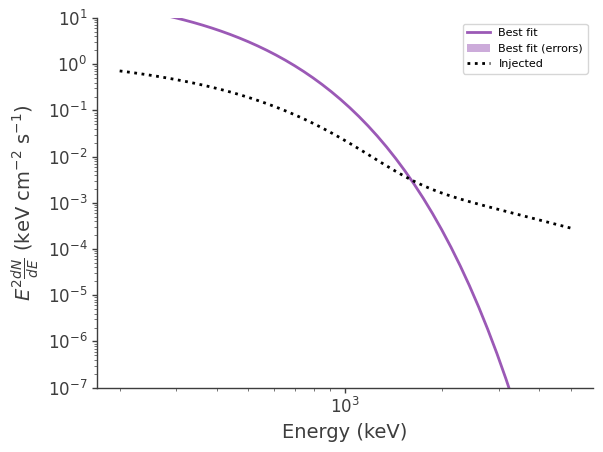

In [11]:
fig, ax = plt.subplots()

ax.plot(energy, energy * energy * flux_median, label="Best fit")
ax.fill_between(energy, energy * energy * flux_lo, energy * energy * flux_hi, alpha=0.5, label="Best fit (errors)")
ax.plot(energy, energy * energy * flux_inj, color="black", ls=":", label="Injected")

colors = {"ngc4151": "tab:red", "ngc1068": "tab:blue"}
if len(fit_source_names) > 1 or fit_include_nonthermal_tail:
    for name in fit_source_names:
        settings = source_settings[name]
        thermal_name = f"{name}_thermal"
        tail_name = f"{name}_tail"
        ax.plot(energy, energy * energy * source_flux_inj[name], color=colors[name], ls=":", label=f"{settings['label']} injected")
        ax.plot(energy, energy * energy * component_flux_median[thermal_name], color=colors[name], ls="--", label=f"{settings['label']} thermal fit")
        if tail_name in component_flux_median:
            ax.plot(energy, energy * energy * component_flux_median[tail_name], color=colors[name], ls="-.", label=f"{settings['label']} non-thermal fit")

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel(r"$E^2 \frac{dN}{dE}$ (keV cm$^{-2}$ s$^{-1}$)")

ax.set_ylim(1e-7, 10)

_ = ax.legend()


Plot the fitted spectrum convolved with the response plus the fitted background, as well as the simulated source+background counts.


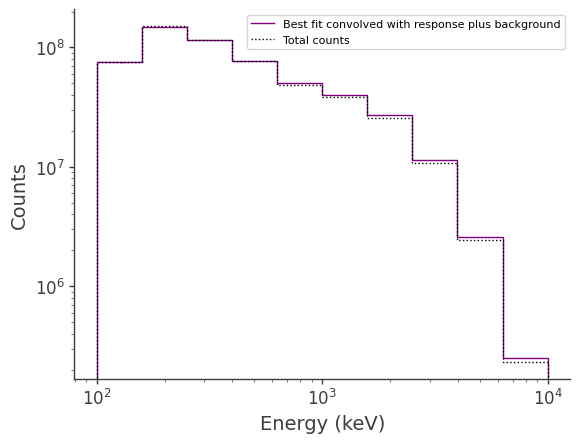

In [13]:
expectation_bkg = bkg.expectation(copy=True)

fig, ax = plt.subplots()

model_counts = expectation.project("Em").to_dense(copy=False).contents + expectation_bkg.project("Em").to_dense(copy=False).contents
data_counts = data.data.project("Em").to_dense(copy=False).contents

ax.stairs(model_counts, binned_energy_edges, color="purple", label="Best fit convolved with response plus background")
ax.errorbar(binned_energy, model_counts, yerr=np.sqrt(model_counts), color="purple", linewidth=0, elinewidth=1)
ax.stairs(data_counts, binned_energy_edges, color="black", ls=":", label="Total counts")
ax.errorbar(binned_energy, data_counts, yerr=np.sqrt(data_counts), color="black", linewidth=0, elinewidth=1)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Counts")

ax.legend()

plt.show()
